In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

SEED = 123
np.random.seed(SEED)

In [74]:

distance_matrix = np.load('../duomenys/dist_mat.npy')
original_data   = np.load('../duomenys/original_data.npy')
labels          = np.load('../duomenys/ship-types.npy')
unique_labels, labels_encoded = np.unique(labels, return_inverse=True)
label_names = {i: name for i, name in enumerate(unique_labels)}

n_samples = original_data.shape[0]
original_flat = original_data.reshape(n_samples, -1)


DISTINCT_COLORS = [
    "#E6194B",  
    "#3CB44B", 
    "#4363D8", 
    "#F58231",  
    "#911EB4",  
]

all_classes = np.unique(labels_encoded)
class_colors = {cls: DISTINCT_COLORS[i % len(DISTINCT_COLORS)]
                for i, cls in enumerate(all_classes)}

embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=SEED
).fit_transform(distance_matrix)

In [75]:
# aibiu padalijimas  (70/30)
idx_train, idx_test = train_test_split(
    np.arange(n_samples), test_size=0.3, random_state=SEED, stratify=labels_encoded
)

X_train_tsne, X_test_tsne = embedding[idx_train], embedding[idx_test]
y_train_tsne, y_test_tsne = labels_encoded[idx_train], labels_encoded[idx_test]

X_train_orig, X_test_orig = original_flat[idx_train], original_flat[idx_test]
y_train_orig, y_test_orig = labels_encoded[idx_train], labels_encoded[idx_test]



In [76]:

# KNN originalioje dimensijoje;
# normavimas + mokymas + metrikos

def run_knn(X_train, X_test, y_train, y_test, label_names, title_prefix, k=5):
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)

    classes = np.unique(np.concatenate([y_train, y_test]))
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    print(f"\n{'='*60}")
    print(f"  {title_prefix}  (k={k})")
    print(f"{'='*60}")
    print("Klasifikavimo lentele (true/pred)")
    cm_df = pd.DataFrame(cm,
                         index=[label_names[c] for c in classes],
                         columns=[label_names[c] for c in classes])
    print(cm_df.to_string())

    n       = cm.sum()
    diag    = np.diag(cm)
    rowsums = cm.sum(axis=1)
    colsums = cm.sum(axis=0)

    precision = np.where(colsums > 0, diag / colsums, 0.0)
    recall    = np.where(rowsums > 0, diag / rowsums, 0.0)
    f1        = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0.0)
    accuracy  = diag.sum() / n

    print("\nMetrikos kiekvienai klasei:")
    print(pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                       index=[label_names[c] for c in classes]).round(4).to_string())
    print(f"\nAccuracy      : {accuracy:.4f}")
    print(f"Macro precision : {precision.mean():.4f}")
    print(f"Macro recall    : {recall.mean():.4f}")
    print(f"Macro F1        : {f1.mean():.4f}")

    return clf, X_train_sc, X_test_sc, scaler



In [77]:
# 2D skiriamieji pavirsiai

def plot_decision_boundary(clf, X_train_sc, X_test_sc,
                           y_train, y_test, label_names,
                           title, ax, step=0.3):
    unique_classes = np.unique(np.concatenate([y_train, y_test]))

    x_min = min(X_train_sc[:,0].min(), X_test_sc[:,0].min()) - 1
    x_max = max(X_train_sc[:,0].max(), X_test_sc[:,0].max()) + 1
    y_min = min(X_train_sc[:,1].min(), X_test_sc[:,1].min()) - 1
    y_max = max(X_train_sc[:,1].max(), X_test_sc[:,1].max()) + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)
    n_classes = len(unique_classes)
    bg_cmap = mcolors.ListedColormap([class_colors[c] for c in unique_classes])
    ax.contourf(xx, yy, Z_idx, alpha=0.25, cmap=bg_cmap,
                levels=np.arange(-0.5, n_classes, 1))

    # Mokymo taškai
    for cls in unique_classes:
        mask = y_train == cls
        ax.scatter(X_train_sc[mask, 0], X_train_sc[mask, 1],
                   c=class_colors[cls], edgecolors='k', s=60,
                   label=label_names[cls], zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=7, loc="best")



  Seed |  k=1 F1  | k=1 Acc |  k=3 F1  | k=3 Acc |  k=5 F1  | k=5 Acc |  k=7 F1  | k=7 Acc |  k=11 F1  | k=11 Acc |  k=15 F1  | k=15 Acc |  k=30 F1  | k=30 Acc
---------------------------------------------------------------------------------------------------------------------------------------------------------------
   123 |  0.7209  |  0.7200  |  0.6521  |  0.6444  |  0.6761  |  0.6711  |  0.6365  |  0.6311  |  0.5519  |  0.5467  |  0.5825  |  0.5778  |  0.5456  |  0.5467 
    42 |  0.7662  |  0.7644  |  0.7484  |  0.7467  |  0.7202  |  0.7200  |  0.6984  |  0.6978  |  0.6286  |  0.6267  |  0.6427  |  0.6400  |  0.5751  |  0.5733 
     7 |  0.7393  |  0.7378  |  0.7356  |  0.7289  |  0.7086  |  0.7022  |  0.6576  |  0.6533  |  0.6461  |  0.6400  |  0.6270  |  0.6222  |  0.5596  |  0.5556 
    99 |  0.7538  |  0.7556  |  0.7139  |  0.7111  |  0.7013  |  0.6978  |  0.6918  |  0.6933  |  0.6456  |  0.6533  |  0.6225  |  0.6222  |  0.5534  |  0.5600 
   256 |  0.6956  |  0.6933  |  0.71

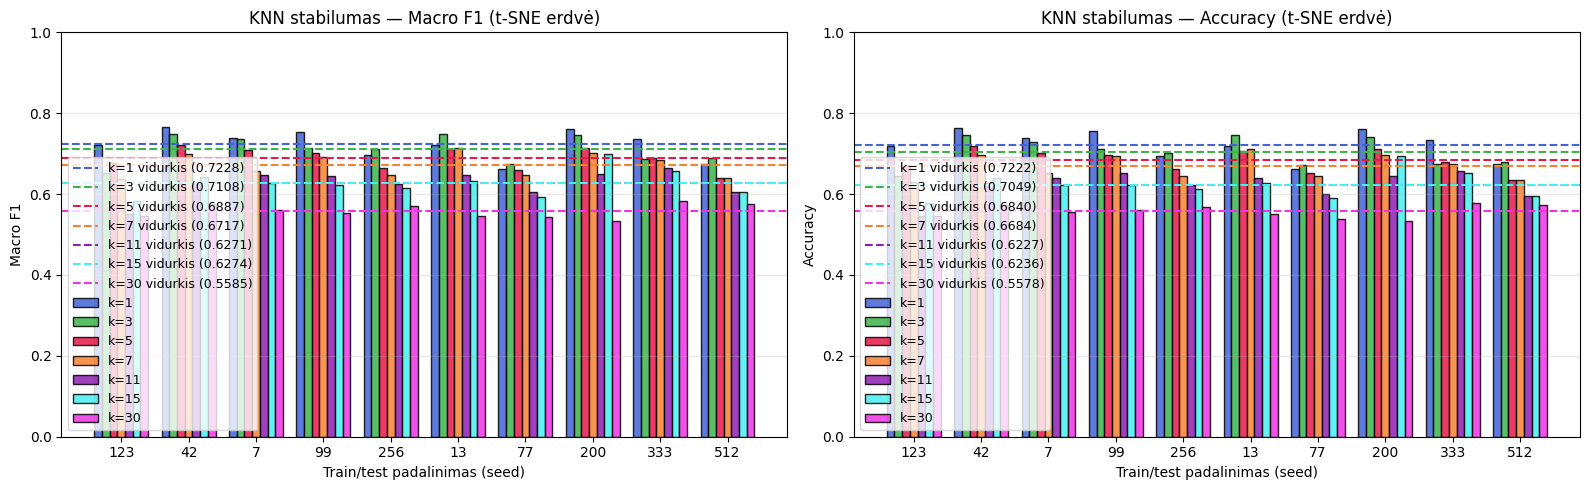

In [ ]:
# Geriausio k rinkimas

SEEDS    = [123, 42, 7, 99, 256, 13, 77, 200, 333, 512]
K_LIST   = [1, 3, 5, 7, 11, 15, 30]
results  = {k: {"f1": [], "acc": []} for k in K_LIST}

for seed in SEEDS:
    idx_tr, idx_te = train_test_split(
        np.arange(n_samples), test_size=0.3,
        random_state=seed, stratify=labels_encoded
    )
    Xtr = embedding[idx_tr]; Xte = embedding[idx_te]
    ytr = labels_encoded[idx_tr]; yte = labels_encoded[idx_te]

    scaler = StandardScaler()
    Xtr_sc = scaler.fit_transform(Xtr)
    Xte_sc = scaler.transform(Xte)

    for k in K_LIST:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(Xtr_sc, ytr)
        y_pred = clf.predict(Xte_sc)
        results[k]["f1"].append(f1_score(yte, y_pred, average='macro', zero_division=0))
        results[k]["acc"].append(accuracy_score(yte, y_pred))

# ── Lentelė
col = " | ".join(f" k={k} F1  | k={k} Acc" for k in K_LIST)
header = f"{'Seed':>6} | {col}"
print(header)
print("-" * len(header))
for i, seed in enumerate(SEEDS):
    vals = " | ".join(
        f" {results[k]['f1'][i]:.4f}  |  {results[k]['acc'][i]:.4f} " for k in K_LIST
    )
    print(f"{seed:>6} | {vals}")

# ── Suvestinė
print("-" * len(header))
for k in K_LIST:
    f1_arr  = np.array(results[k]["f1"])
    acc_arr = np.array(results[k]["acc"])
    print(f"k={k:>2}  |  F1  vidurkis={f1_arr.mean():.4f}  std={f1_arr.std():.4f}"
          f"  min={f1_arr.min():.4f}  max={f1_arr.max():.4f}")
    print(f"     |  Acc vidurkis={acc_arr.mean():.4f}  std={acc_arr.std():.4f}"
          f"  min={acc_arr.min():.4f}  max={acc_arr.max():.4f}")

# ── Vizualizacija — F1 ir Accuracy šalia
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(SEEDS))

n_k = len(K_LIST)
width = 0.8 / n_k  # visa grupė tilptų į vieną x poziciją

colors_k = {
    1:  "#4363D8",
    3:  "#3CB44B",
    5:  "#E6194B",
    7:  "#F58231",
    11: "#911EB4",
    15: "#46F0F0",
    30: "#F032E6",
}

for ax, metric, ylabel in zip(axes3, ["f1", "acc"], ["Macro F1", "Accuracy"]):
    for ki, k in enumerate(K_LIST):
        vals = results[k][metric]

        # skirtingas poslinkis kiekvienam k
        offset = (ki - (n_k - 1) / 2) * width

        ax.bar(
            x + offset,
            vals,
            width,
            label=f'k={k}',
            color=colors_k[k],
            alpha=0.85,
            edgecolor='k'
        )

        ax.axhline(
            np.mean(vals),
            color=colors_k[k],
            linestyle='--',
            linewidth=1.5,
            label=f'k={k} vidurkis ({np.mean(vals):.4f})'
        )

    ax.set_xlabel("Train/test padalinimas (seed)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"KNN stabilumas — {ylabel} (t-SNE erdvė)")
    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in SEEDS])
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('./plots/knn_stability.svg', format='svg')
plt.show()


In [79]:
# KNN klasifikavimas 2D

print("\nKNN klasifikavimas sumažintoje 2D dimensijoje (t-SNE)")
clf_tsne, Xtr_tsne_sc, Xte_tsne_sc, sc_tsne = run_knn(
    X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne,
    label_names, title_prefix="t-SNE erdvė", k=1
)


KNN klasifikavimas sumažintoje 2D dimensijoje (t-SNE)

  t-SNE erdvė  (k=1)
Klasifikavimo lentele (true/pred)
           Cargo  Fishing  Passenger  Pilot  Tanker
Cargo         29        7          2      1       6
Fishing        5       32          1      0       7
Passenger      3        1         31      4       6
Pilot          1        3          4     37       0
Tanker         5        4          1      2      33

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.6744  0.6444  0.6591
Fishing       0.6809  0.7111  0.6957
Passenger     0.7949  0.6889  0.7381
Pilot         0.8409  0.8222  0.8315
Tanker        0.6346  0.7333  0.6804

Accuracy      : 0.7200
Macro precision : 0.7251
Macro recall    : 0.7200
Macro F1        : 0.7209


In [ ]:
# KNN klasifikavimas originaliems duomenims
print("\nKNN klasifikavimas originaliems duomenims")
clf_orig, Xtr_orig_sc, Xte_orig_sc, sc_orig = run_knn(
    X_train_orig, X_test_orig, y_train_orig, y_test_orig,
    label_names, title_prefix="Originalūs duomenys", k=5
)



### KNN — Originalūs duomenys (išlyginti) ###

  Originalūs duomenys (flat)  (k=5)
Klasifikavimo lentele (true/pred)
           Cargo  Fishing  Passenger  Pilot  Tanker
Cargo         35        9          1      0       0
Fishing        8       32          1      3       1
Passenger      4        5         29      2       5
Pilot          7        2          8     28       0
Tanker        14        4          1      1      25

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.5147  0.7778  0.6195
Fishing       0.6154  0.7111  0.6598
Passenger     0.7250  0.6444  0.6824
Pilot         0.8235  0.6222  0.7089
Tanker        0.8065  0.5556  0.6579

Accuracy      : 0.6622
Macro precision : 0.6970
Macro recall    : 0.6622
Macro F1        : 0.6657


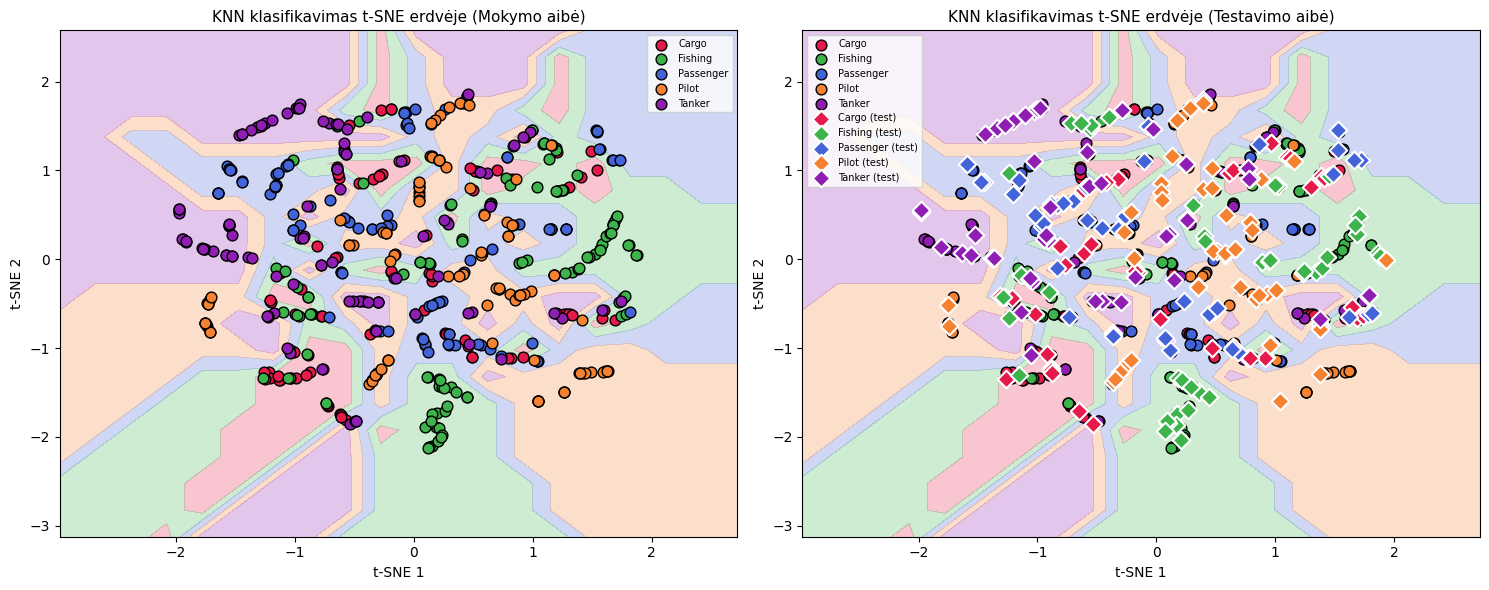

In [ ]:

# sumazintoje erdveje (tsne 2d) mokymosi ir testavimo aibiu rezultatai su skiriamuoju pavirsiu

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_decision_boundary(clf_tsne, Xtr_tsne_sc, Xte_tsne_sc,
                       y_train_tsne, y_test_tsne, label_names,
                       title="KNN klasifikavimas t-SNE erdvėje (Mokymo aibė)", ax=axes[0])


plot_decision_boundary(clf_tsne, Xtr_tsne_sc, Xte_tsne_sc,
                       y_train_tsne, y_test_tsne, label_names,
                       title="KNN klasifikavimas t-SNE erdvėje (Testavimo aibė)", ax=axes[1])

for cls in np.unique(y_test_tsne):
    mask = y_test_tsne == cls
    axes[1].scatter(Xte_tsne_sc[mask, 0], Xte_tsne_sc[mask, 1],
                    c=class_colors[cls], edgecolors='white',
                    linewidths=1.5, s=80, marker='D', zorder=4,
                    label=f"{label_names[cls]} (test)")

axes[1].legend(fontsize=7, loc="best")
plt.tight_layout()
# plt.savefig('./plots/knn_2d_boundary.svg', format="svg")
plt.show()

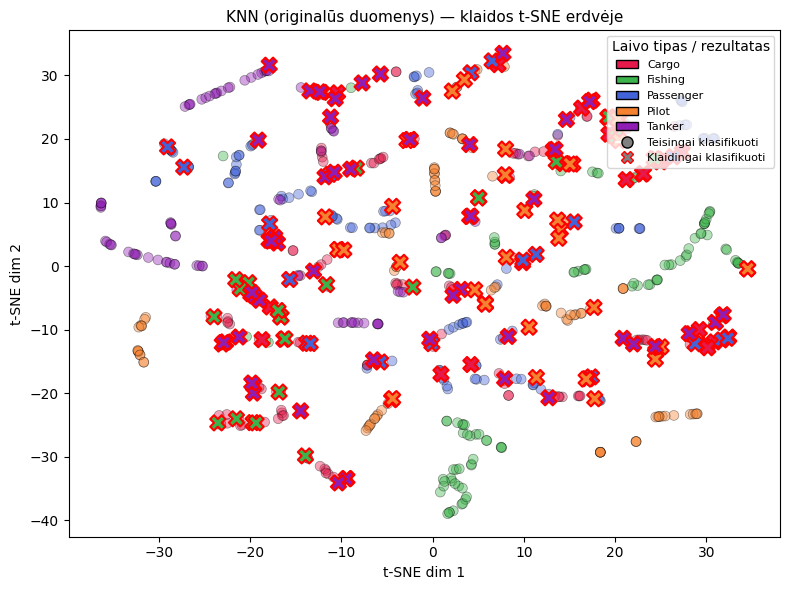

In [ ]:

# originaliu duomenu klaidos t-SNE 

fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred_full = clf_orig.predict(sc_orig.transform(original_flat))
correct = y_pred_full == labels_encoded

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(embedding[correct, 0], embedding[correct, 1],
            c=[class_colors[c] for c in labels_encoded[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(embedding[~correct, 0], embedding[~correct, 1],
            c=[class_colors[c] for c in labels_encoded[~correct]],
            s=120, edgecolors='red', linewidths=1.5, marker='X', alpha=1.0, zorder=3)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
class_patches = [Patch(facecolor=class_colors[i], edgecolor='k',
                       label=label_names[i]) for i in unique_cls]
marker_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='k', markersize=8, label='Teisingai klasifikuoti'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor='gray',
           markeredgecolor='red', markersize=8, label='Klaidingai klasifikuoti'),
]
ax2.legend(handles=class_patches + marker_handles, fontsize=8,
           loc='upper right', title="Laivo tipas / rezultatas")
ax2.set_title("KNN (originalūs duomenys) — klaidos t-SNE erdvėje", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/knn_errors_orig.svg', format='svg')
plt.show()
